# Hello, Graph World!

This notebook is a "beachhead" introduction to graph data structures using **NetworkX**, a Python library for the creation, manipulation, and study of complex networks.

We'll build and visualize the **Krackhardt Kite Graph** — a classic example from social network analysis created by David Krackhardt in 1990. It's commonly used to illustrate different types of network centrality (degree, betweenness, closeness), making it a great first graph to explore.

---

## 1. Install & Import Libraries

We need two libraries:
- **NetworkX** — for creating and analyzing the graph
- **Matplotlib** — for drawing and visualizing it

In [2]:
# Uncomment the line below if you need to install NetworkX
# !pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt

print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.2.1


---
## 2. Create the Graph

The Krackhardt Kite has **10 nodes** (labeled 1–10) and **18 edges**. Each node represents a person, and each edge represents a relationship between two people.

We define the nodes and edges explicitly, then add them to an undirected `Graph` object.

In [3]:
# Create an undirected graph
G = nx.Graph()

# --- Nodes ---
# Each node represents a person in the social network
nodes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
G.add_nodes_from(nodes)

# --- Edges ---
# Each tuple represents a relationship (connection) between two people
edges = [
    (1, 2), (1, 3), (1, 4), (1, 6),
    (2, 4), (2, 5), (2, 7),
    (3, 4), (3, 6),
    (4, 5), (4, 6), (4, 7),
    (5, 7),
    (6, 7), (6, 8),
    (7, 8),
    (8, 9),
    (9, 10)
]
G.add_edges_from(edges)

print(f"Nodes ({G.number_of_nodes()}): {list(G.nodes())}")
print(f"Edges ({G.number_of_edges()}): {list(G.edges())}")

Nodes (10): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Edges (18): [(1, 2), (1, 3), (1, 4), (1, 6), (2, 4), (2, 5), (2, 7), (3, 4), (3, 6), (4, 5), (4, 6), (4, 7), (5, 7), (6, 7), (6, 8), (7, 8), (8, 9), (9, 10)]


---
## 3. Visualize the Graph

We use a **fixed layout** that approximates the classic kite shape described by Krackhardt. Nodes are colored and sized to make the structure easy to read.

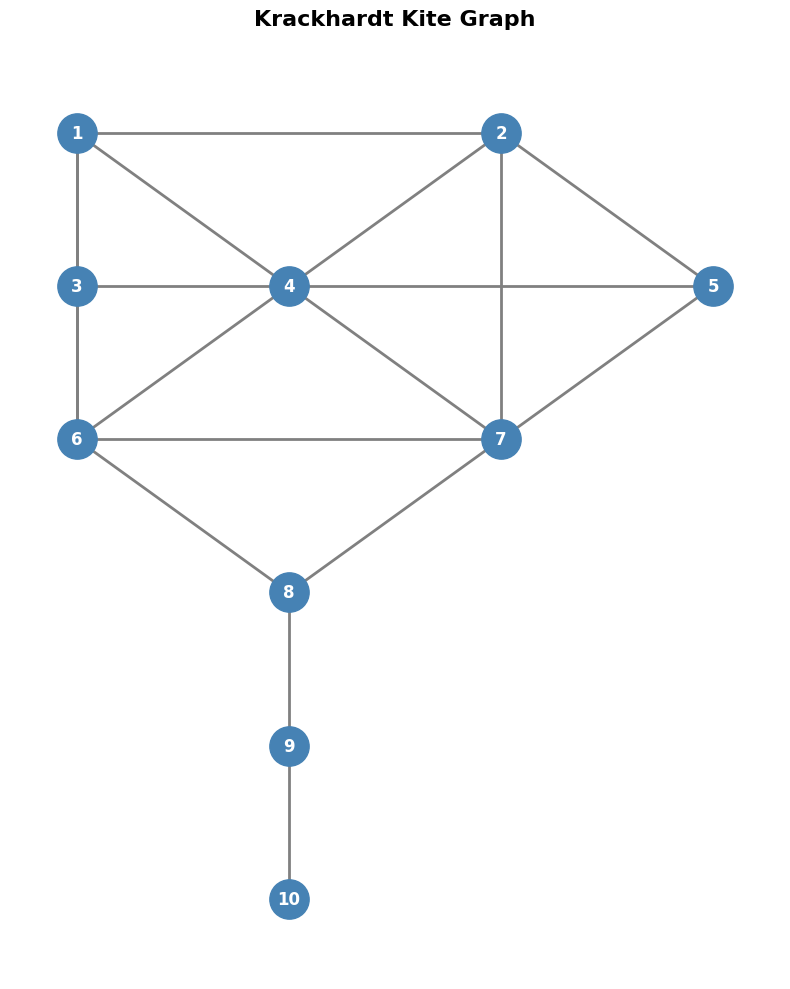

In [4]:
# Fixed positions to approximate the classic Krackhardt Kite layout
pos = {
    1: (0, 2),
    2: (2, 2),
    3: (0, 1),
    4: (1, 1),
    5: (3, 1),
    6: (0, 0),
    7: (2, 0),
    8: (1, -1),
    9: (1, -2),
    10: (1, -3)
}

plt.figure(figsize=(8, 10))

# Draw the graph
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color="steelblue",
    node_size=800,
    font_color="white",
    font_size=12,
    font_weight="bold",
    edge_color="gray",
    width=2
)

plt.title("Krackhardt Kite Graph", fontsize=16, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

---
## 4. Basic Graph Statistics

One of the most useful things about NetworkX is how easy it is to compute graph metrics. Let's explore a few fundamental ones.

In [5]:
print("=== Basic Graph Info ===")
print(f"Number of nodes : {G.number_of_nodes()}")
print(f"Number of edges : {G.number_of_edges()}")
print(f"Is connected    : {nx.is_connected(G)}")
print(f"Graph density   : {nx.density(G):.4f}")

print("\n=== Degree of Each Node ===")
print("(How many connections each person has)")
for node, degree in sorted(G.degree(), key=lambda x: -x[1]):
    print(f"  Node {node:>2}: degree {degree}")

=== Basic Graph Info ===
Number of nodes : 10
Number of edges : 18
Is connected    : True
Graph density   : 0.4000

=== Degree of Each Node ===
(How many connections each person has)
  Node  4: degree 6
  Node  6: degree 5
  Node  7: degree 5
  Node  1: degree 4
  Node  2: degree 4
  Node  3: degree 3
  Node  5: degree 3
  Node  8: degree 3
  Node  9: degree 2
  Node 10: degree 1


---
## 5. Centrality Analysis

The Krackhardt Kite is especially famous for demonstrating that **different centrality measures highlight different "important" nodes**:

| Measure | What it captures | Most central node |
|---|---|---|
| **Degree centrality** | Most connections | Node 4 |
| **Betweenness centrality** | Acts as a bridge | Node 8 |
| **Closeness centrality** | Fastest to reach all others | Node 6 or 7 |

Let's verify this computationally.

In [6]:
degree_cent     = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
closeness_cent  = nx.closeness_centrality(G)

print(f"{'Node':<6} {'Degree':>10} {'Betweenness':>14} {'Closeness':>12}")
print("-" * 46)
for node in sorted(G.nodes()):
    print(f"{node:<6} {degree_cent[node]:>10.4f} {betweenness_cent[node]:>14.4f} {closeness_cent[node]:>12.4f}")

print(f"\nHighest degree centrality    → Node {max(degree_cent, key=degree_cent.get)}")
print(f"Highest betweenness centrality → Node {max(betweenness_cent, key=betweenness_cent.get)}")
print(f"Highest closeness centrality  → Node {max(closeness_cent, key=closeness_cent.get)}")

Node       Degree    Betweenness    Closeness
----------------------------------------------
1          0.4444         0.0231       0.5294
2          0.4444         0.0231       0.5294
3          0.3333         0.0000       0.5000
4          0.6667         0.1019       0.6000
5          0.3333         0.0000       0.5000
6          0.5556         0.2315       0.6429
7          0.5556         0.2315       0.6429
8          0.3333         0.3889       0.6000
9          0.2222         0.2222       0.4286
10         0.1111         0.0000       0.3103

Highest degree centrality    → Node 4
Highest betweenness centrality → Node 8
Highest closeness centrality  → Node 6


---
## 6. Summary

In this notebook we:

1. **Created** a graph by explicitly defining nodes and edges using NetworkX
2. **Visualized** the Krackhardt Kite in its classic layout using Matplotlib
3. **Computed** basic statistics (size, density, degree)
4. **Analyzed** centrality to see how different measures identify different influential nodes

This is just the starting point — NetworkX supports directed graphs, weighted edges, graph algorithms (shortest paths, clustering, community detection), and much more.

---
*Reference: Krackhardt, D. (1990). Assessing the political landscape: Structure, cognition, and power in organizations. Administrative Science Quarterly, 35(2), 342–369.*